## Regenerate figures from saved artifacts (optional)

Re-renders every seed's four PNGs under `results/figures/[TAG/]` from the
already-saved `results/sweep_artifacts/[TAG/]seed_N.joblib` bundles -- no MCMC or
surrogate training re-run, just the current `msd_plots.py` code applied to existing
data. Run this after any `msd_plots.py` change (styling, new panels, ...) to refresh
the PNGs the display cells below read; skip it if the figures on disk are already
current, or if you have no artifacts yet (run `python run.py --n-seeds 25` first).

In [1]:
from run import _artifacts_dir, _save_figures, load_artifact

TAG = ""  # match whatever --tag run.py was invoked with; "" for the untagged default

seeds = sorted(int(p.stem.split("_")[1]) for p in _artifacts_dir(TAG).glob("seed_*.joblib"))
if not seeds:
    print(f"No artifacts found under {_artifacts_dir(TAG)} -- run `python run.py --n-seeds 25` first.")
else:
    for seed in seeds:
        artifact = load_artifact(seed, tag=TAG)
        _save_figures(
            artifact["problem"], problem_seed=seed, tag=TAG,
            seed_surrogate=artifact["seed_surrogate"], offline_surrogate=artifact["offline_surrogate"],
            chains_by_method=artifact["chains_by_method"], surrogates_by_method=artifact["surrogates_by_method"],
            posterior=artifact["posterior"],
        )
    print(f"Regenerated figures for {len(seeds)} seed(s): {seeds}")


Regenerated figures for 25 seed(s): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


# Mass-spring-damper benchmark: adaptive delayed-acceptance MCMC vs. baselines

A mass-spring-damper released from rest, `m x'' + c x' + k x = 0`. Mass is fixed; the
unknowns are stiffness `k` and damping `c`, inferred from a noisy observed trajectory.

**Four inference strategies** (the comparison harness lives in
`gp_active_mcmc.verification`; only the physics/problem setup is specific to this
example, in `msd.py`/`msd_methods.py`):

1. **HF-only Metropolis-Hastings** -- ground-truth reference; every step calls the
   expensive high-fidelity (HF) forward model.
2. **Pretrained** -- a POD-GP surrogate trained offline via greedy max-variance active
   learning, then frozen and used as if exact (the "Pretrained Model" arm in Riccius
   et al., 2025).
3. **Adaptive surrogate MCMC** (`adaptive_surrogate_mcmc`, Riccius, synced) -- the
   surrogate is substituted for the likelihood and refined online via an uncertainty
   threshold, with no delayed-acceptance (DA) correction (Riccius et al. 2025,
   Algorithm 1); every replicate's individually-collected HF points are additionally
   pooled into a shared surrogate each round.
4. **Adaptive STM** (`adaptive_stm`, ours) -- the surrogate is refined online during an
   adaptive phase, guided by the MCMC path; once its accuracy stabilizes it is frozen
   and a delayed-acceptance chain generates the production samples, which carry the DA
   stationarity guarantee (unlike methods 2 and 3).

**Two comparisons.** Comparing `pretrained`'s frozen, uncorrected posterior directly
against `adaptive_stm`'s DA-corrected posterior would only show that DA correction
removes surrogate bias -- true, but not this work's contribution. So the two questions
are kept separate:

- **Training cost**: `adaptive_stm`'s online, MCMC-path-guided adaptive phase vs.
  `pretrained`'s offline, global active-learning procedure -- how much HF budget each
  needs to reach a trustworthy surrogate.
- **Posterior accuracy**: `hf_only` vs. `adaptive_surrogate_mcmc` vs. `adaptive_stm`
  (`pretrained` excluded, per above). `adaptive_surrogate_mcmc` stays in this
  comparison to show that continual online refinement *without* DA correction still
  doesn't recover the true posterior.

**Noise level.** `sigma_obs=0.059`, chosen at a 25% noise-to-signal ratio (mean
per-trajectory RMS amplitude over the prior, post-transient -- see the `nsr25` sweep
tag): looser than the tight-noise (`sigma_obs=0.024`, NSR=10%) sensitivity variant
explored earlier, still tighter than the original default (`sigma_obs=0.1`).
`gamma_threshold=0.0059` (kept at the fixed `0.1 * sigma_obs` ratio used throughout).

All results below are aggregated over 25 independent problem instances, produced by
`run.py --n-seeds 25 --sigma-obs 0.059 --gamma-threshold 0.0059 --tag nsr25`.


### Methods and naming

Every problem-agnostic piece of the comparison (`run_hf_only`, `run_pretrained`,
`run_adaptive_stm`, `run_convergence_driven_comparison`, the R-hat-driven multi-chain
round loop, the W2/KL/pooled-summary metrics) lives in `gp_active_mcmc.verification`,
tested and shared with `examples/navier_stokes/`; only the physics/problem setup
(`Problem`, `build_problem`, this problem's calibrated constants) is defined locally in
`msd_methods.py`. `adaptive_surrogate_mcmc` (the Riccius-style baseline) is built from
`run_convergence_driven_comparison`'s own orchestration rather than a standalone
`run_*` function, since its distinguishing behavior -- pooling every replicate's HF
points into a shared surrogate each round -- is a property of the multi-chain loop,
not a single-chain method.


In [2]:
from __future__ import annotations

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from msd_methods import PARAM_NAMES, RESULTS_DIR, build_problem
from msd_plots import plot_accuracy_boxplots, plot_training_cost_boxplot

FIGURES_DIR = RESULTS_DIR / "figures/"
SWEEP_PATH = RESULTS_DIR / "sweep_convergence_driven.jsonl"

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Problem setup

One example problem instance: `theta_true` drawn from the prior, and a noisy
synthetic observation of the resulting trajectory.


In [3]:
problem = build_problem(problem_seed=0, sigma_obs=0.059)
print("theta_true:", dict(zip(PARAM_NAMES, problem.theta_true.tolist(), strict=True)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(problem.t, problem.hf_forward(problem.theta_true), lw=2, label="clean HF")
ax.plot(problem.t, problem.y_obs, ".", ms=3, alpha=0.5, label="noisy observation")
ax.set_xlabel("t [s]")
ax.set_ylabel("x(t)")
ax.legend()
ax.set_title(f"True trajectory (theta_true={np.round(problem.theta_true, 3)})")
fig.tight_layout()


theta_true: {'k': 52.514604421867865, 'c': 0.9669737841771745}


## Running the comparison

`run.py --n-seeds 25 --sigma-obs 0.059 --gamma-threshold 0.0059 --tag nsr25` runs both
comparisons above for 25 independent problem instances (fresh `theta_true`/observation
and offline seed design each) and saves per-seed metrics to
`results/sweep_convergence_driven_nsr25.jsonl` and per-seed figures to
`results/figures/nsr25/`. This notebook loads and aggregates that output. (This sweep
was run with `--skip-training-cost`, so the training-cost section below has no data
for it -- that comparison isn't specific to this noise level and doesn't need
re-running per sigma_obs.)


In [4]:
if not SWEEP_PATH.exists():
    print(f"{SWEEP_PATH} not found -- run `python run.py --n-seeds 25` first.")
    sweep_rows = []
else:
    sweep_rows = [json.loads(line) for line in SWEEP_PATH.read_text().splitlines() if line.strip()]
    print(f"Loaded {len(sweep_rows)} seed(s) from {SWEEP_PATH}")


Loaded 25 seed(s) from /Users/filippozacchei/COde/MFDA_ActiveLearning/examples/toy_problem/results/sweep_convergence_driven.jsonl


## Example: surrogate fit and posterior (seed 0)

One example from the sweep: the trained surrogate's prediction at `theta_true` for
each method (top), and the pooled posterior for
`hf_only`/`adaptive_surrogate_mcmc`/`adaptive_stm` (bottom), each pooled across its
replicate chains at its own R-hat-validated burn-in. The same figures are saved for
every seed in `results/figures/`.


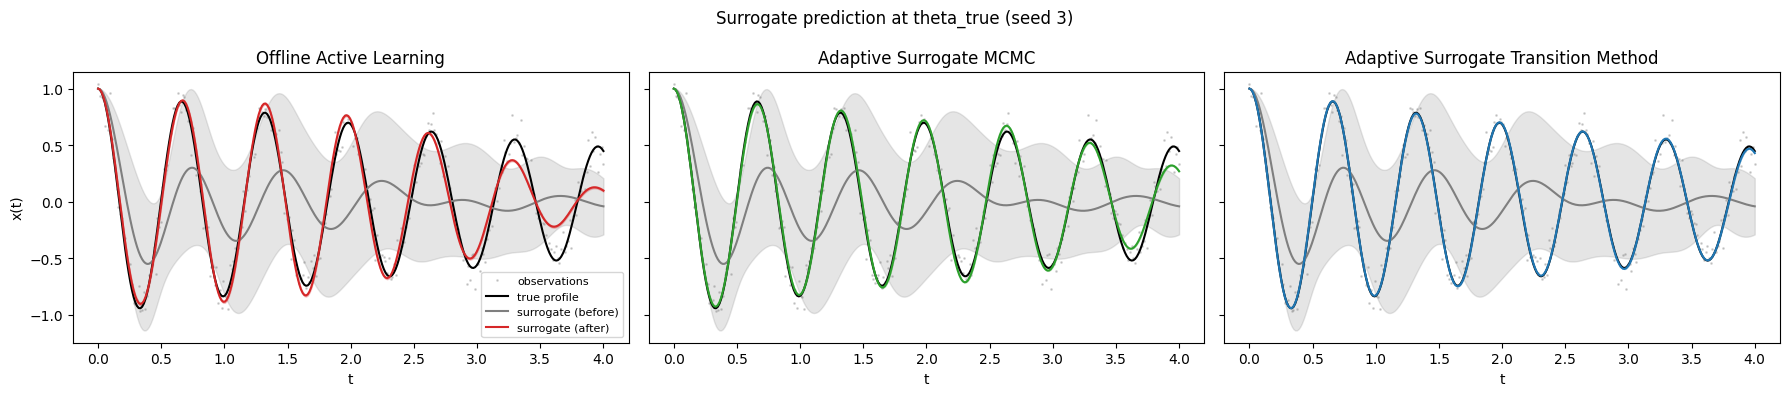

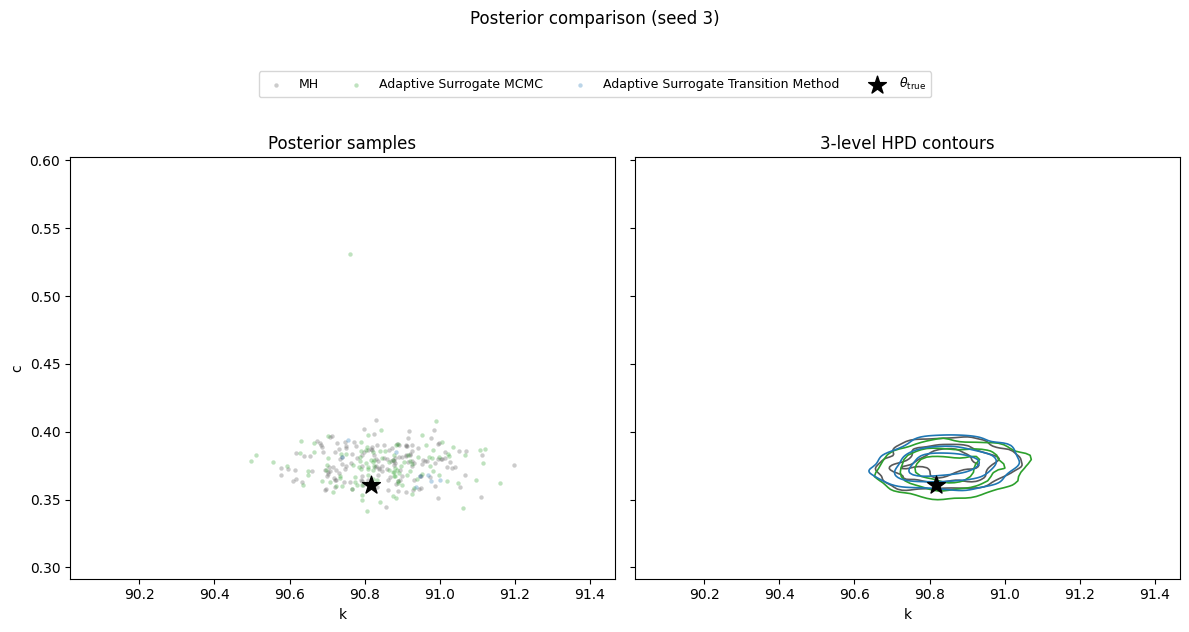

In [5]:
example_seed = sweep_rows[3]["seed"] if sweep_rows else 0
display(Image(filename=str(FIGURES_DIR / f"surrogate_comparison_seed_{example_seed}.png")))
display(Image(filename=str(FIGURES_DIR / f"posterior_scatter_seed_{example_seed}.png")))


### Where each method's active learning actually explored (seed 0)

Both start from the same `seed_X` shared offline design; from there, `pretrained`
acquires points via purely-offline, global max-predictive-variance search, while
`adaptive_stm` acquires them online, guided by its own MCMC path during its adaptive
phase. Reloaded from the saved artifact -- no re-run.

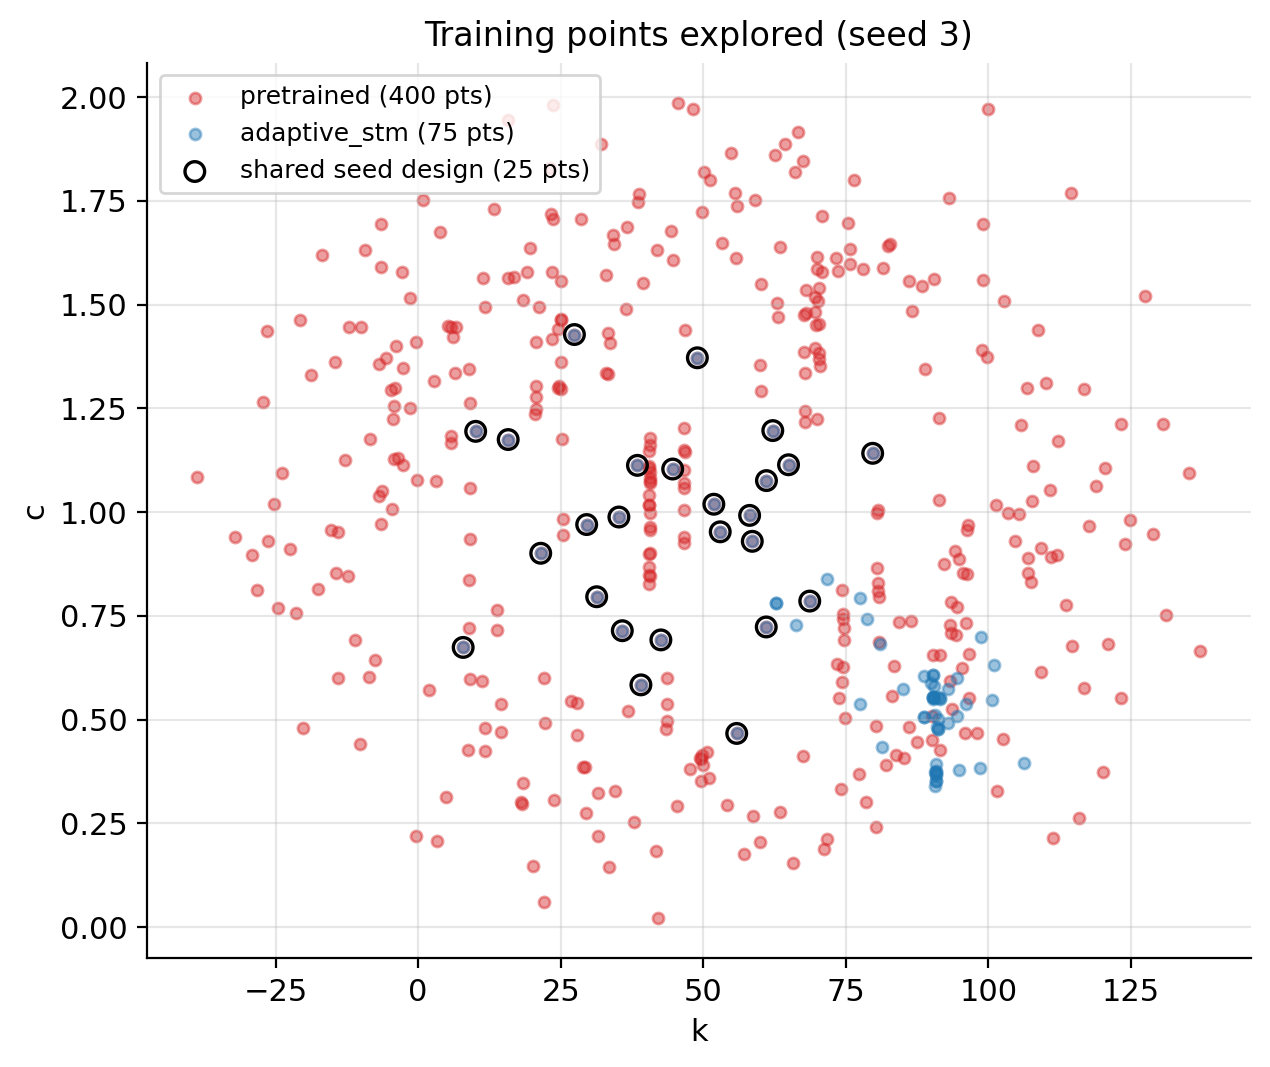

In [6]:
def _offline_training_X(surrogate):
    """Points `active_learning_offline_design` actually trained on. Prefers
    `X_history` (persisted for any run using the now-fixed
    `gp_active_mcmc.verification.design`); falls back to unscaling the fitted GP's
    own stored data for older artifacts saved before that fix."""
    if surrogate.X_history is not None:
        return surrogate.X_history
    inner = surrogate.gp._gps[0]
    return inner._x_scaler.inverse_transform(inner._gp.X)


example_artifact = load_artifact(example_seed, tag=TAG)
offline_X = _offline_training_X(example_artifact["offline_surrogate"])
stm_X = example_artifact["surrogates_by_method"]["adaptive_stm"][0].X_history
seed_X = example_artifact["seed_X"]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(
    offline_X[:, 0], offline_X[:, 1], s=16, alpha=0.45, color="tab:red",
    label=f"pretrained ({offline_X.shape[0]} pts)",
)
ax.scatter(
    stm_X[:, 0], stm_X[:, 1], s=16, alpha=0.45, color="tab:blue",
    label=f"adaptive_stm ({stm_X.shape[0]} pts)",
)
ax.scatter(
    seed_X[:, 0], seed_X[:, 1], s=50, facecolors="none", edgecolors="k", linewidths=1.2,
    label=f"shared seed design ({seed_X.shape[0]} pts)", zorder=5,
)
ax.set_xlabel("k")
ax.set_ylabel("c")
ax.legend(fontsize=9)
ax.set_title(f"Training points explored (seed {example_seed})")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "training_points.png", bbox_inches="tight")
display(Image(filename=str(FIGURES_DIR / f"training_points.png")))



## Training-cost comparison

Extra HF evaluations beyond the shared offline seed design -- `adaptive_stm`'s online
adaptive phase vs. `pretrained`'s offline active-learning procedure -- across all
seeds.


        offline_extra_hf  online_extra_hf
mean          492.000000        67.600000
median        525.000000        58.000000
std            88.893663        25.982366

adaptive_stm's adaptive-phase convergence rate: 100.0%


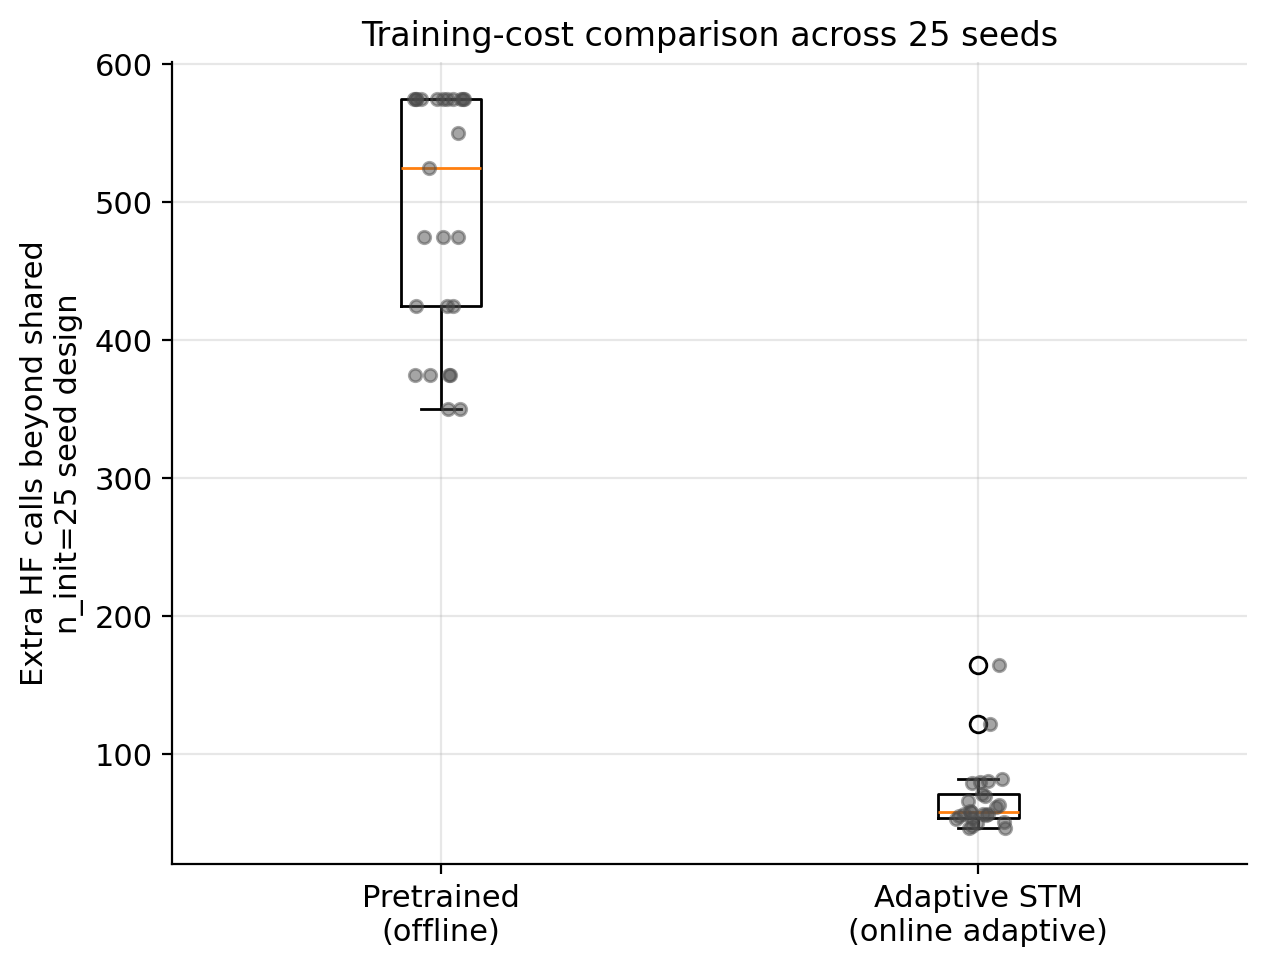

In [7]:
tc_rows = [r for r in sweep_rows if r["training_cost"] is not None]
if not tc_rows:
    print(
        f"No training-cost data in these {len(sweep_rows)} seed(s) -- this sweep was run with "
        "--skip-training-cost. Rerun without that flag to populate this section."
    )
else:
    if len(tc_rows) < len(sweep_rows):
        print(f"Note: only {len(tc_rows)}/{len(sweep_rows)} seed(s) have training-cost data; the rest were "
              "presumably run with --skip-training-cost and are excluded below.")

    tc_df = pd.DataFrame([
        {
            "seed": r["seed"],
            "offline_extra_hf": r["training_cost"]["offline"]["n_hf_extra"],
            "online_extra_hf": r["training_cost"]["online"]["n_hf_extra"],
            "online_converged": r["training_cost"]["online"]["converged"],
        }
        for r in tc_rows
    ])
    print(tc_df[["offline_extra_hf", "online_extra_hf"]].agg(["mean", "median", "std"]))
    print(f"\nadaptive_stm's adaptive-phase convergence rate: {tc_df['online_converged'].mean():.1%}")

    fig = plot_training_cost_boxplot(
        tc_df["offline_extra_hf"].to_numpy(), tc_df["online_extra_hf"].to_numpy(), n_init=tc_rows[0]["n_init"]
    )
    fig.savefig(FIGURES_DIR / "training_cost_sweep.png", bbox_inches="tight")
    display(Image(filename=str(FIGURES_DIR / f"training_cost_sweep.png")))


## Posterior-accuracy comparison

Cost to reach R-hat<=1.01 across 5 replicate chains, and distributional distance
(Wasserstein-2, KL) to the `hf_only` reference posterior, across all seeds.


method
adaptive_stm               0.92
adaptive_surrogate_mcmc    0.92
hf_only                    1.00
Name: convergence_rate, dtype: float64

                        total_coarse_evals                      n_hf_calls  \
                                      mean  median          std       mean   
method                                                                       
adaptive_stm                        5160.0  4200.0  2338.446778    1062.00   
adaptive_surrogate_mcmc             3624.0  2600.0  2254.122150     164.52   
hf_only                             2396.0  2400.0   719.073478   11985.00   

                                                 w2_ref                       \
                          median          std      mean    median        std   
method                                                                         
adaptive_stm               870.0   467.689356  0.009999  0.008756   0.005263   
adaptive_surrogate_mcmc     77.0   193.396424  7.090058  0.026504  2

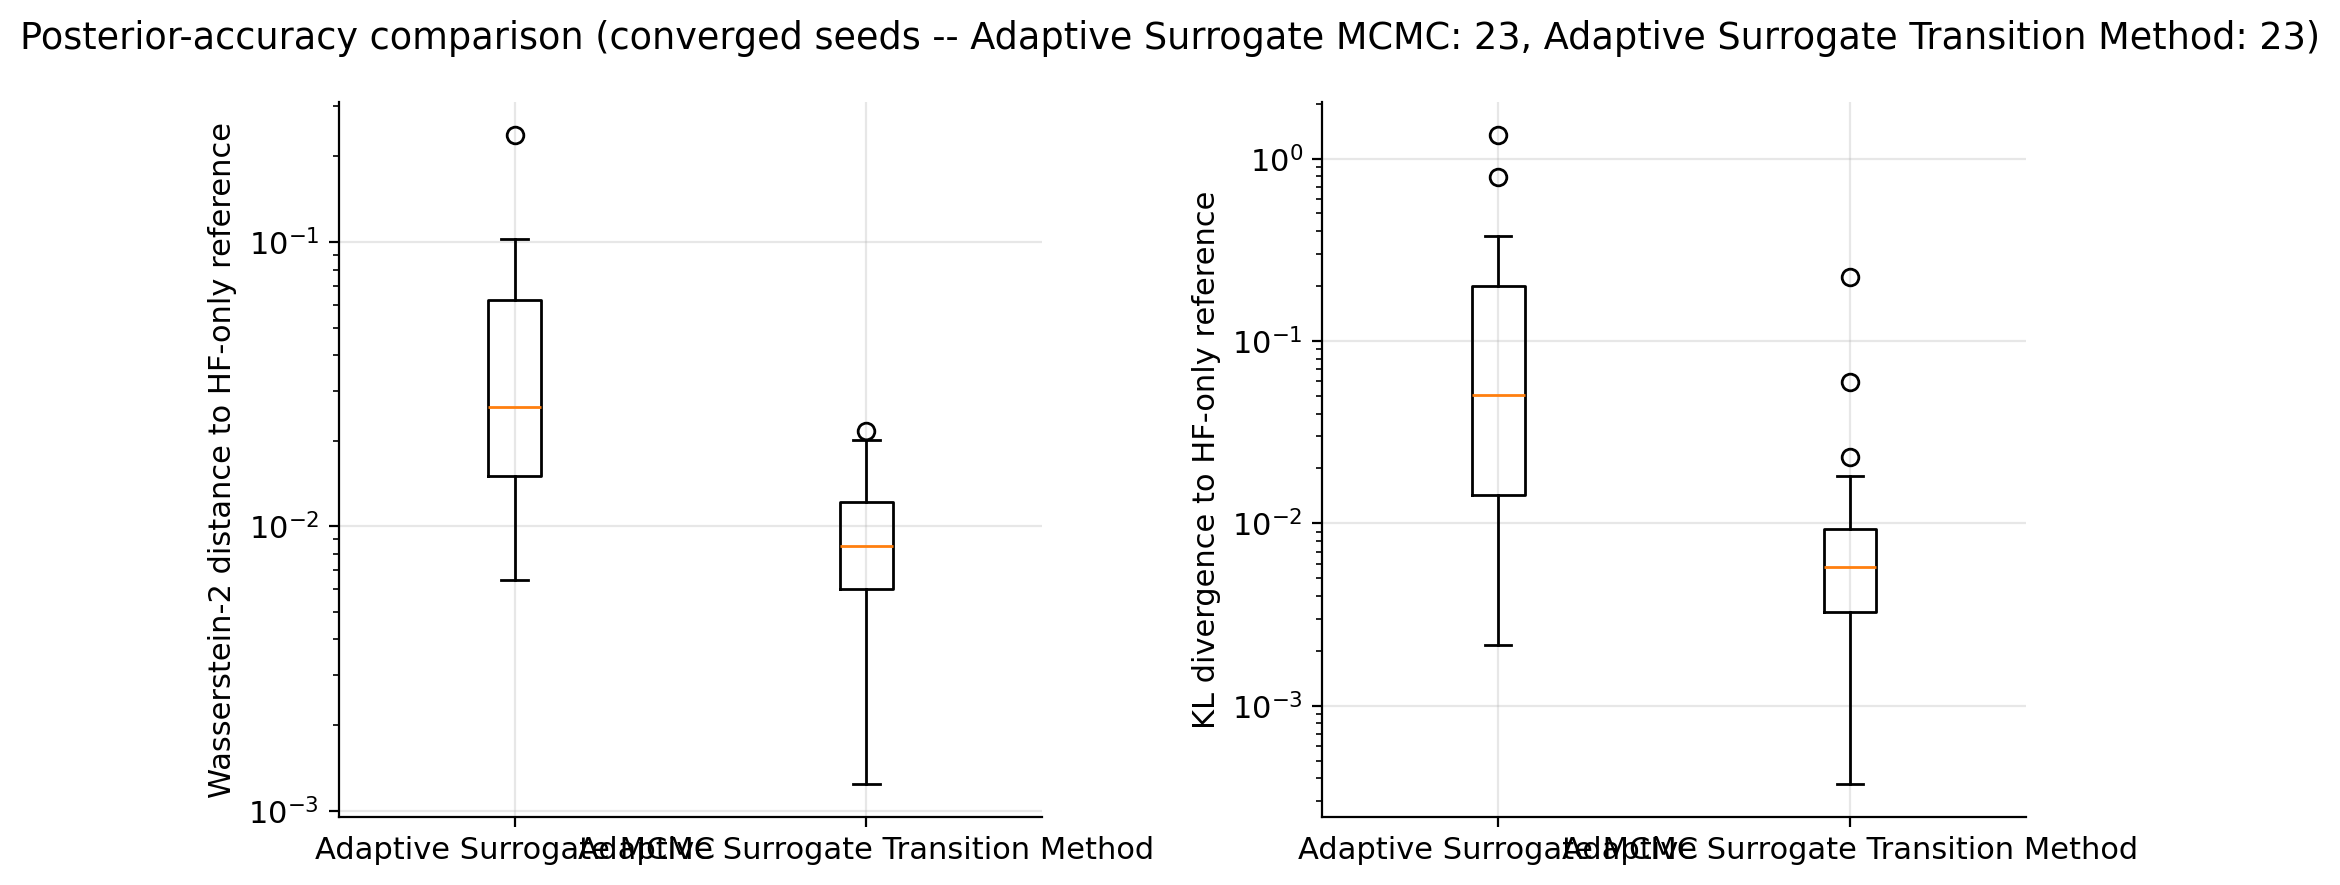

In [8]:
candidate_methods = ("hf_only", "adaptive_surrogate_mcmc", "adaptive_stm")

pa_rows = []
for r in sweep_rows:
    for method in candidate_methods:
        p = r["posterior"].get(method)
        if p is None:
            continue  # e.g. an older row saved before the online_active_synced -> adaptive_surrogate_mcmc rename
        pooled = p.get("pooled", {})
        # Replica 0's POD rank/refit count -- adaptive_surrogate_mcmc's replicates are
        # normally identical (synced every round, see the sync-hook discussion above),
        # and adaptive_stm always has exactly one. hf_only has no surrogate at all, and
        # older rows saved before this metric existed have no "surrogate_stats" key.
        surrogate_stats = r.get("surrogate_stats", {}).get(method, {})
        pod_rank = surrogate_stats.get("pod_rank", [None])[0]
        pod_refit_count = surrogate_stats.get("pod_refit_count", [None])[0]
        pa_rows.append({
            "seed": r["seed"],
            "method": method,
            "converged": p["converged"],
            "total_coarse_evals": p["total_coarse_evals"],
            "n_hf_calls": pooled.get("n_hf_calls"),
            "w2_ref": pooled.get("wasserstein2_to_reference"),
            "kl_ref": pooled.get("kl_to_reference"),
            "rmse": pooled.get("rmse_to_truth"),
            "pod_rank": pod_rank,
            "pod_refit_count": pod_refit_count,
        })
pa_df = pd.DataFrame(pa_rows)
print(pa_df.groupby("method")["converged"].mean().rename("convergence_rate"))
print()
print(pa_df.groupby("method")[
    ["total_coarse_evals", "n_hf_calls", "w2_ref", "kl_ref", "rmse", "pod_rank", "pod_refit_count"]
].agg(["mean", "median", "std"]))

method_order = ("adaptive_surrogate_mcmc", "adaptive_stm")
converged = pa_df[pa_df["converged"]]
w2_by_method = {m: converged.loc[converged["method"] == m, "w2_ref"].dropna().to_numpy() for m in method_order}
kl_by_method = {m: converged.loc[converged["method"] == m, "kl_ref"].dropna().to_numpy() for m in method_order}

fig = plot_accuracy_boxplots(w2_by_method, kl_by_method, method_order=method_order)
fig.savefig(FIGURES_DIR / "posterior_accuracy_sweep.png", bbox_inches="tight")
display(Image(filename=str(FIGURES_DIR / f"posterior_accuracy_sweep.png")))
